## PE 10: Time Series Data Analysis in Pandas

In this exercise, you will retrieve historical stock data from Yahoo Finance using the yfinance library, and perform a series of time series manipulations using Python and Pandas. You will explore concepts such as datetime.datetime, formatting and parsing dates, Pandas time series basics, creating date ranges, working with different frequencies, shifting, resampling, frequency conversion, moving windows, and plotting the data.

Libraries Required:

    1. pandas

    2. yfinance
    
    3. matplotlib

#### 1. Install and import the necessary libraries: pandas, yfinance, and matplotlib.

In [9]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime

#### 2. Retrieve Historical Stock Data:

> Use the yfinance library to download historical stock data for a company of your choice (e.g., Apple Inc., ticker: AAPL).

> Retrieve data for the past 2 years.

> Show the resulting DataFrame: Top 10 and Last 10

In [6]:
# Download 2 years of AAPL stock data
startDate = datetime(2023, 1, 1)
endDate = datetime(2025, 1, 1)

stock = yf.download("AAPL", start=startDate, end=endDate)

# Top 10
print("Top 10:")
print(stock.head(10))

# Last 10
print("\nLast 10:")
print(stock.tail(10))

[*********************100%***********************]  1 of 1 completed

Top 10:
Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  122.982712  128.715409  122.097730  128.105761  112117500
2023-01-04  124.251183  126.512801  122.992546  124.772336   89113600
2023-01-05  122.933540  125.637646  122.677885  125.008327   80962700
2023-01-06  127.456779  128.115596  122.805722  123.907033   87754700
2023-01-09  127.977913  131.183516  127.722257  128.292580   70790800
2023-01-10  128.548248  129.069402  125.981806  128.086091   63896200
2023-01-11  131.262207  131.281862  128.282776  129.059585   69458900
2023-01-12  131.183533  132.019338  129.246409  131.645690   71379600
2023-01-13  132.511017  132.668350  129.462761  129.826581   57809700
2023-01-17  133.671326  134.998787  131.891535  132.579850   63646600

Last 10:
Price            Close        High         Low        Open     Volume
Ti

#### 3. Explore your data and perform necessary data cleaning and preparation:

a. Handling Missing Data and Duplicates

> Identify any missing data in the time series.

> Use different techniques to handle missing data, such as forward fill, backward fill, and interpolation.

> Identify and remove duplicates

b. Parse dates

> ensure that you have parse the date column into a datetime format and you are using the date column as the index.

In [7]:
# Check for missing data
print("Missing values:\n", stock.isnull().sum())

# Forward fill
stock_ffill = stock.ffill()
print("\nForward filled:\n", stock_ffill.isnull().sum())

# Backward fill
stock_bfill = stock.bfill()
print("\nBackward filled:\n", stock_bfill.isnull().sum())

# Interpolation
stock_interp = stock.interpolate()
print("\nInterpolated:\n", stock_interp.isnull().sum())

# Check and remove duplicates
print("\nDuplicate rows:", stock.duplicated().sum())
stock = stock[~stock.duplicated()]
print("After removing duplicates:", stock.shape)

Missing values:
 Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

Forward filled:
 Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

Backward filled:
 Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

Interpolated:
 Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

Duplicate rows: 0
After removing duplicates: (502, 5)


In [10]:
print("Index type:", type(stock.index))
print("Index dtype:", stock.index.dtype)

# Reset and re-parse just to demonstrate
stock.index = pd.to_datetime(stock.index)
print("\nParsed DatetimeIndex:\n", stock.index)

Index type: <class 'pandas.DatetimeIndex'>
Index dtype: datetime64[s]

Parsed DatetimeIndex:
 DatetimeIndex(['2023-01-03', '2023-01-04', '2023-01-05', '2023-01-06',
               '2023-01-09', '2023-01-10', '2023-01-11', '2023-01-12',
               '2023-01-13', '2023-01-17',
               ...
               '2024-12-17', '2024-12-18', '2024-12-19', '2024-12-20',
               '2024-12-23', '2024-12-24', '2024-12-26', '2024-12-27',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[s]', name='Date', length=502, freq=None)


Note: Show results of the above process.

#### 4. Create a variable that stores the formated date that displays a 'Month-Day-Year' format. Show the result.

In [11]:
formatted_dates = stock.index.strftime("%m-%d-%Y")
print("Formatted dates (Month-Day-Year):")
print(formatted_dates[:5])

Formatted dates (Month-Day-Year):
Index(['01-03-2023', '01-04-2023', '01-05-2023', '01-06-2023', '01-09-2023'], dtype='str', name='Date')


#### 5. Time Series Basics

Explore the basic attributes of the time series and print the output:
1. index frequency
2. first date
3. last date
4. time period covered

In [12]:
# 1. Index frequency
print("Index frequency:", stock.index.freq)

# 2. First date
print("First date:", stock.index.min())

# 3. Last date
print("Last date:", stock.index.max())

# 4. Time period covered
time_period = stock.index.max() - stock.index.min()
print("Time period covered:", time_period)

Index frequency: None
First date: 2023-01-03 00:00:00
Last date: 2024-12-31 00:00:00
Time period covered: 728 days 00:00:00


#### 6. Creating Date Ranges and Frequencies

Create a new date range that represents the last business day of each month and filter the original DataFrame to include only these dates. Print the result.

In [13]:
# Create date range of last business day of each month
end_of_month_dates = pd.date_range(
    start=stock.index.min(),
    end=stock.index.max(),
    freq='BME'
)

# Filter original DataFrame for those dates
end_of_month_df = stock[stock.index.isin(end_of_month_dates)]
print("End-of-month business day data:")
print(end_of_month_df)

End-of-month business day data:
Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-31  141.881927  141.931096  139.905478  140.318467   65874500
2023-02-28  145.171204  146.815839  144.600011  144.816671   50547000
2023-03-31  162.395569  162.494056  159.450989  159.972939   68749800
2023-04-28  167.102966  167.270398  165.330316  165.931052   55275900
2023-05-31  174.799454  176.870426  174.316223  174.878350   99625300
2023-06-30  191.288330  191.791274  188.615790  188.980685   85213200
2023-07-31  193.733994  193.773449  192.560443  193.349386   38824100
2023-08-31  185.522797  186.757179  185.137670  185.493173   60794500
2023-09-29  169.070984  170.907746  168.211843  169.870862   51861100
2023-10-31  168.636475  168.764840  165.802321  167.234217   44846000
2023-11-30  187.823929  188.189798  186.083634  187.715159

#### 7. Shifting and Rolling Windows

Shift the stock prices by 1 day forward and backward.

Calculate a 7-day rolling mean of the Close price.

In [14]:
# Shift 1 day forward
stock_forward = stock.shift(1)
print("Shifted 1 day forward (head):")
print(stock_forward.head())

# Shift 1 day backward
stock_backward = stock.shift(-1)
print("\nShifted 1 day backward (tail):")
print(stock_backward.tail())

# 7-day rolling mean of Close price
rolling_7 = stock['Close'].rolling(7).mean()
print("\n7-day rolling mean of Close:")
print(rolling_7.head(15))

Shifted 1 day forward (head):
Price            Close        High         Low        Open       Volume
Ticker            AAPL        AAPL        AAPL        AAPL         AAPL
Date                                                                   
2023-01-03         NaN         NaN         NaN         NaN          NaN
2023-01-04  122.982712  128.715409  122.097730  128.105761  112117500.0
2023-01-05  124.251183  126.512801  122.992546  124.772336   89113600.0
2023-01-06  122.933540  125.637646  122.677885  125.008327   80962700.0
2023-01-09  127.456779  128.115596  122.805722  123.907033   87754700.0

Shifted 1 day backward (tail):
Price            Close        High         Low        Open      Volume
Ticker            AAPL        AAPL        AAPL        AAPL        AAPL
Date                                                                  
2024-12-24  257.375580  258.448740  255.994420  256.550862  27237100.0
2024-12-26  253.967377  257.057649  251.453440  256.193146  42355300.0
2024-12

#### 8. Resampling and Frequency Conversion

Resample the stock data to a weekly frequency, calculating the mean Close price for each week.

Resample the stock data to an hourly frequency, fill the missing values with mean values.

In [15]:
# Weekly resample - mean Close price
weekly_close = stock['Close'].resample('W').mean()
print("Weekly mean Close price:")
print(weekly_close.head(10))

# Hourly resample - fill missing with mean
hourly_stock = stock.resample('h').mean()
hourly_stock = hourly_stock.fillna(hourly_stock.mean())
print("\nHourly resampled (head):")
print(hourly_stock.head(10))

Weekly mean Close price:
Ticker            AAPL
Date                  
2023-01-08  124.406054
2023-01-15  130.296584
2023-01-22  133.801594
2023-01-29  140.690173
2023-02-05  145.144571
2023-02-12  149.544016
2023-02-19  151.393250
2023-02-26  146.121548
2023-03-05  145.275592
2023-03-12  149.177417

Hourly resampled (head):
Price                     Close        High         Low        Open  \
Ticker                     AAPL        AAPL        AAPL        AAPL   
Date                                                                  
2023-01-03 00:00:00  122.982712  128.715409  122.097730  128.105761   
2023-01-03 01:00:00  187.896247  189.387127  186.136364  187.626462   
2023-01-03 02:00:00  187.896247  189.387127  186.136364  187.626462   
2023-01-03 03:00:00  187.896247  189.387127  186.136364  187.626462   
2023-01-03 04:00:00  187.896247  189.387127  186.136364  187.626462   
2023-01-03 05:00:00  187.896247  189.387127  186.136364  187.626462   
2023-01-03 06:00:00  187.896247  1

#### 9. Moving Windows

Apply a moving window calculation on the stock prices to determine the 30-day moving average.

Plot the original Close price and the 30-day moving average on the same graph.

<Figure size 1200x600 with 0 Axes>

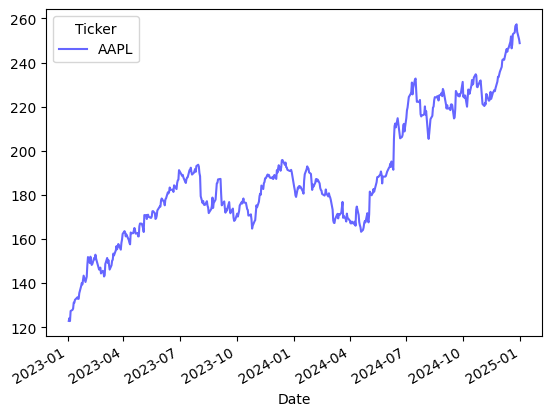

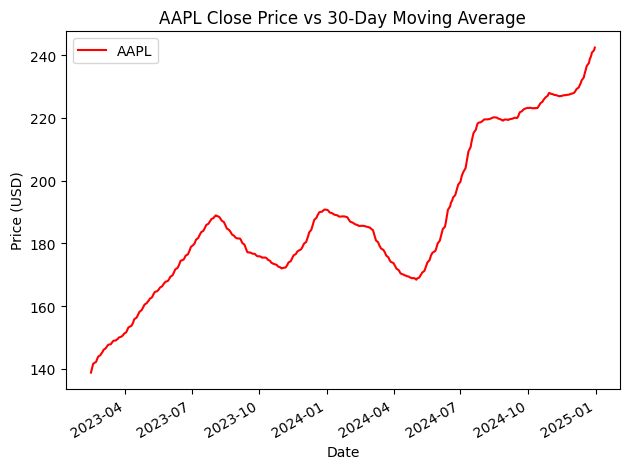

In [16]:
# 30-day moving average
sma_30 = stock['Close'].rolling(30).mean()

# Plot
plt.figure(figsize=(12, 6))
stock['Close'].plot(style='b-', label='Close Price', alpha=0.6)
sma_30.plot(style='r-', label='30-Day Moving Avg')
plt.title('AAPL Close Price vs 30-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

#### Question:
How does the 30-day moving average smooth the fluctuations in the original price, and how does this compare to the raw price series over time?

The 30-day moving average smooths out short-term fluctuations by averaging 
prices over a 30-day window, resulting in a much smoother curve compared to 
the raw price series. The raw series reacts immediately to daily volatility 
and news events, while the moving average lags slightly behind but reveals 
the overall trend more clearly.

#### 10. Percentage Change
Calculate the percentage change of the stock close price and the rolling standard deviation over a 30-day period.

Plot the results with the original 'Close' price.

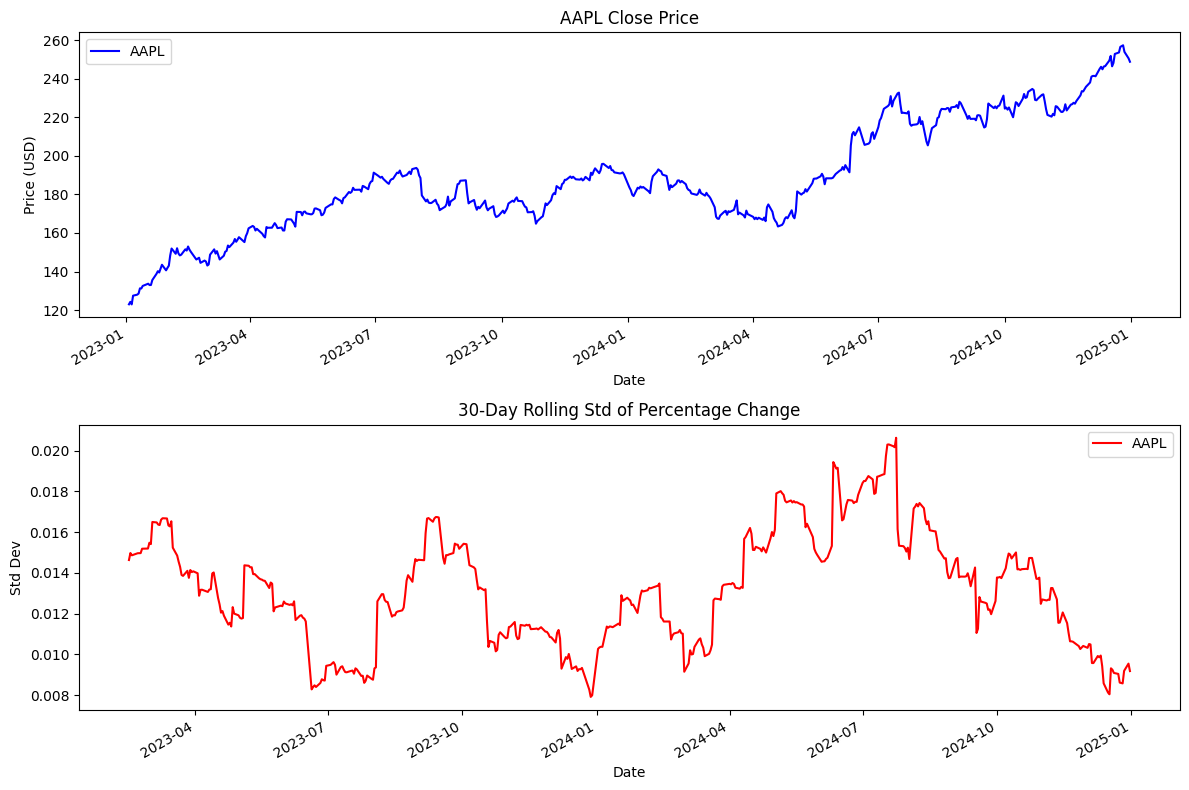

In [17]:
# Percentage change
pct_change = stock['Close'].pct_change()

# 30-day rolling standard deviation
rolling_std = pct_change.rolling(30).std()

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

stock['Close'].plot(ax=ax1, style='b-', label='Close Price')
ax1.set_title('AAPL Close Price')
ax1.set_ylabel('Price (USD)')
ax1.legend()

rolling_std.plot(ax=ax2, style='r-', label='30-Day Rolling Std of % Change')
ax2.set_title('30-Day Rolling Std of Percentage Change')
ax2.set_ylabel('Std Dev')
ax2.legend()

plt.tight_layout()
plt.show()

#### 11. Expanding Mean
Calculate the expanding mean of the above output then plot both.

<Figure size 1200x600 with 0 Axes>

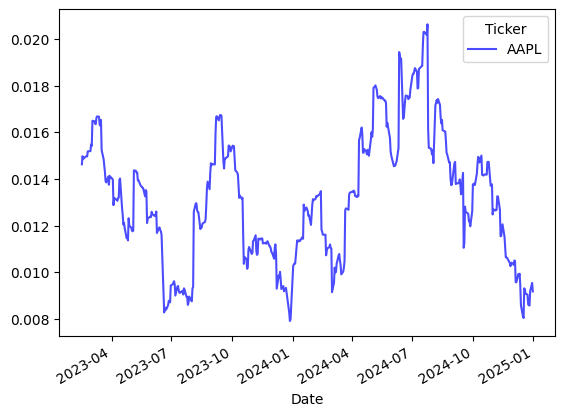

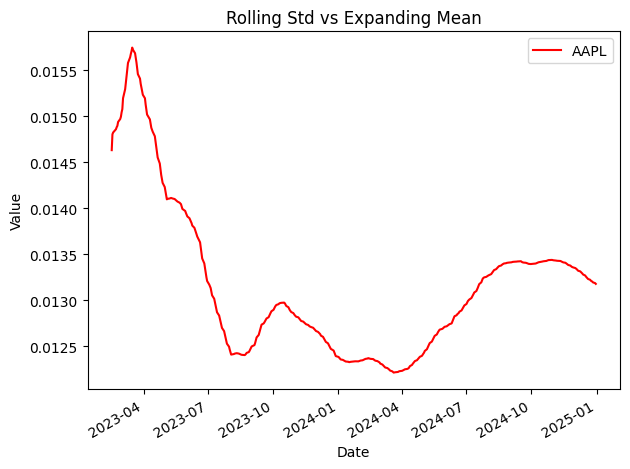

In [18]:
# Expanding mean of rolling std
expanding_mean = rolling_std.expanding().mean()

# Plot both
plt.figure(figsize=(12, 6))
rolling_std.plot(style='b-', label='30-Day Rolling Std', alpha=0.7)
expanding_mean.plot(style='r-', label='Expanding Mean')
plt.title('Rolling Std vs Expanding Mean')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

#### Question:
How does the cumulative percentage change of the price compare to the cumulative expanding mean of the percentage change over a specific period?

The rolling std of percentage change captures short-term volatility bursts, 
spiking during turbulent market periods and dropping during calm ones. The 
expanding mean, by contrast, continuously averages all values up to each 
point in time, so it starts sensitive to early spikes but gradually stabilizes 
as more data accumulates. Over time the expanding mean converges toward the 
long-run average volatility, smoothing out the noise and providing a clearer 
picture of the overall volatility trend.

#### 12. Exponentially Weighted Moving Average
Calculate the exponentially weighted moving average of the stock close price over a 30-day period.

Plot the above output with the original close price, 30-day moving average from Step 9. Customize the plot to show the title, legend with labels, and different line style and colors to differentiate each.

<Figure size 1200x600 with 0 Axes>

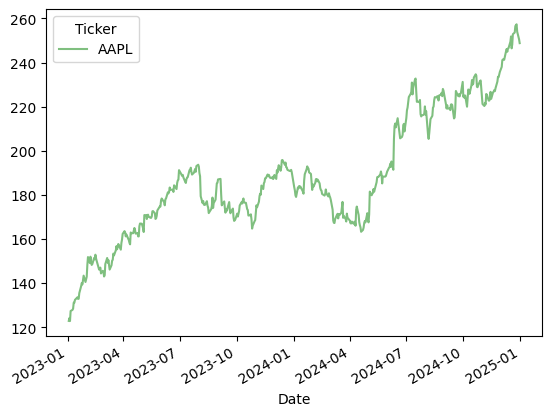

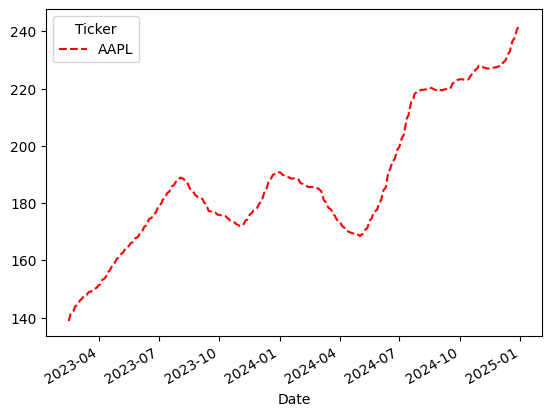

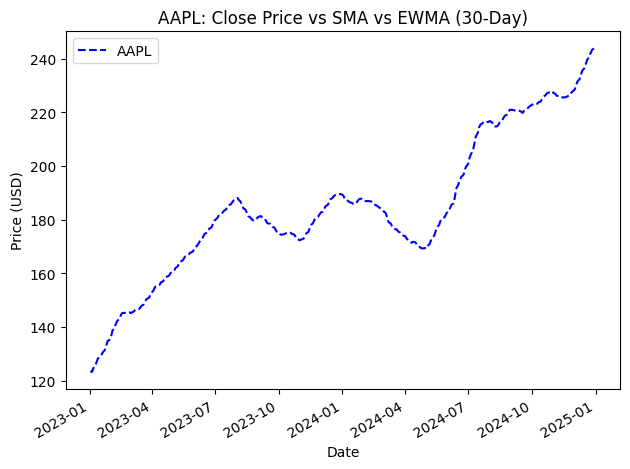

In [19]:
ewm_30 = stock['Close'].ewm(span=30).mean()
plt.figure(figsize=(12, 6))
stock['Close'].plot(style='g-', label='Close Price', alpha=0.5)
sma_30.plot(style='r--', label='30-Day Simple Moving Avg')
ewm_30.plot(style='b--', label='30-Day EW Moving Avg')
plt.title('AAPL: Close Price vs SMA vs EWMA (30-Day)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

#### Question:
How does the Exponentially Weighted Moving Average (EWMA) smooth the fluctuations in the original price, and how does this compare to the raw price series over time?

Like the SMA, the EWMA smooths short-term fluctuations in the raw price 
series, but it reacts faster to recent price changes because it assigns 
exponentially higher weights to more recent observations. This means the 
EWMA tracks the actual price more closely during trend reversals compared 
to the SMA, which treats all 30 days equally and lags further behind. Over 
longer stable periods both converge, but in volatile stretches the EWMA 
is more responsive while still filtering out day-to-day noise.

## Note: Output(s) for each step should be shown or printed.